# 📊 Exploratory Data Analysis on Retail Sales Data
**Track:** Data Analytics — Level 1, Task 1
**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Dataset:** Retail Sales Dataset — 1000 individual customer transactions across Beauty, Clothing, and Electronics categories, including customer Age and Gender.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = pd.read_csv('retail_sales_dataset.csv')
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 1. Initial Inspection

Shape, column data types, and null value check — the very first thing to do before any analysis.

In [2]:
print("Shape of dataset:", df.shape)
print("\nColumn Data Types:\n")
print(df.dtypes)


Shape of dataset: (1000, 9)

Column Data Types:

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object


In [3]:
print("Null values per column:\n")
print(df.isnull().sum())
print("\nTotal duplicate rows:", df.duplicated().sum())


Null values per column:

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Total duplicate rows: 0


**Observation:** The dataset has 1,000 transactions across 9 columns with **zero null values and zero duplicates** — it's clean and ready for analysis straight away. We have Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, and Total Amount to work with.

## 2. Data Preparation

Convert `Date` to datetime and engineer Month/Quarter columns for the time series analysis, plus an Age Group column for demographics analysis.

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

bins = [0, 18, 25, 35, 45, 55, 100]
labels = ['Under 18', '18-25', '26-35', '36-45', '46-55', '56+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

df[['Date', 'Month', 'Quarter', 'Age', 'Age Group']].head()


,Date,Month,Quarter,Age,Age Group
0,2023-11-24,2023-11,2023Q4,34,26-35
1,2023-02-27,2023-02,2023Q1,26,26-35
2,2023-01-13,2023-01,2023Q1,50,46-55
3,2023-05-21,2023-05,2023Q2,37,36-45
4,2023-05-06,2023-05,2023Q2,30,26-35


## 3. Descriptive Statistics

Mean, median, mode, and standard deviation for all numerical columns.

In [5]:
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
desc = df[numeric_cols].describe().T
desc['mode'] = df[numeric_cols].mode().iloc[0]
desc[['mean', '50%', 'mode', 'std', 'min', 'max']].rename(columns={'50%': 'median'})


,mean,median,mode,std,min,max
Age,41.392,42.0,43.0,13.681430,18.0,64.0
Quantity,2.514,3.0,4.0,1.132734,1.0,4.0
Price per Unit,179.890,50.0,50.0,189.681356,25.0,500.0
Total Amount,456.000,135.0,50.0,559.997632,25.0,2000.0


**Observation:** Average customer age is ~41 years with a fairly wide spread (std ~13.7), meaning the customer base spans a broad age range rather than being concentrated around one group. Average transaction value is ~\$456, but the standard deviation is very high relative to the mean — a sign of large price differences between categories (Electronics/Clothing being pricier than Beauty). Average quantity per transaction is ~2.5 units.

## 4. Time Series Analysis — Monthly & Quarterly Sales Trends

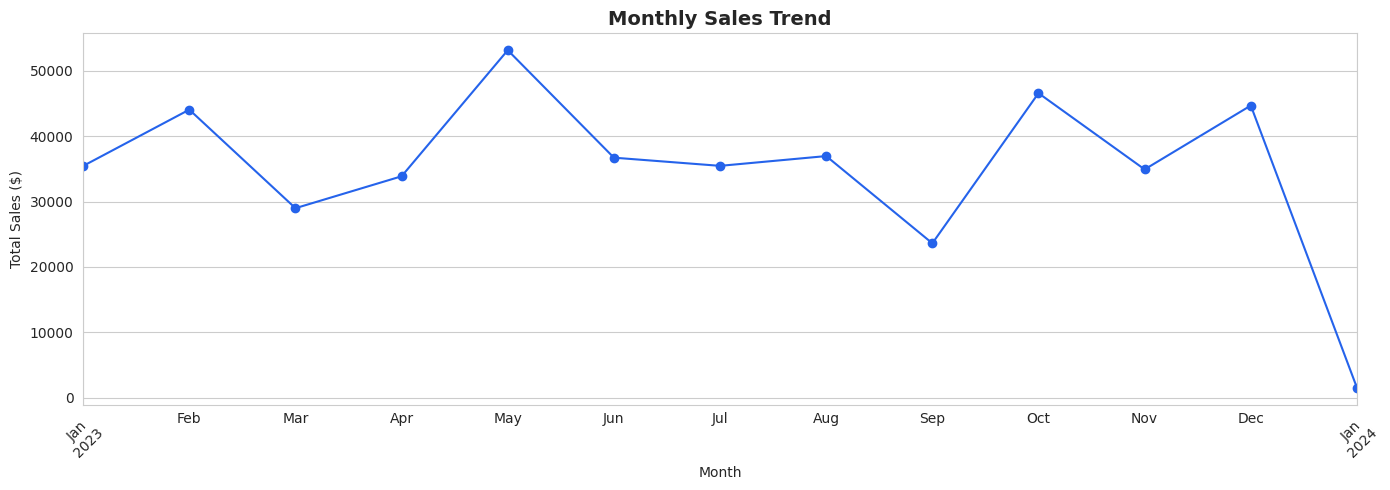

In [6]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(14, 5))
monthly_sales.plot(kind='line', marker='o', color='#2563eb')
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


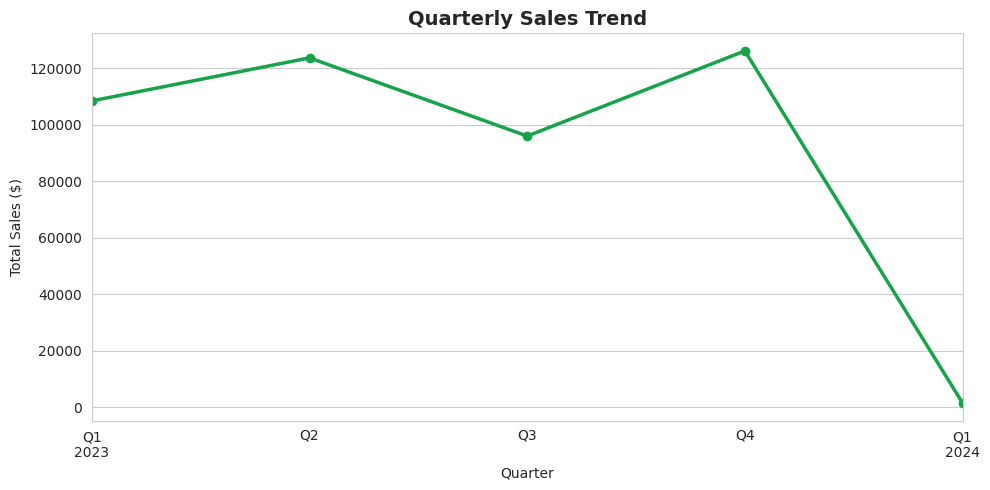

In [7]:
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

plt.figure(figsize=(10, 5))
quarterly_sales.plot(kind='line', marker='o', color='#16a34a', linewidth=2.5)
plt.title('Quarterly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()


**Observation:** Monthly sales fluctuate quite a bit without one dominant seasonal peak — there are a couple of noticeably strong months (e.g. May) and a few noticeably weak ones, but no single clear upward or downward trend across the year. At the quarterly level, the trend smooths out a bit, but Q2 stands out as the strongest quarter overall, suggesting a spring sales bump worth investigating further (possible promotions or seasonal categories driving it).

## 5. Customer Demographics Analysis — Age Groups & Gender Breakdown

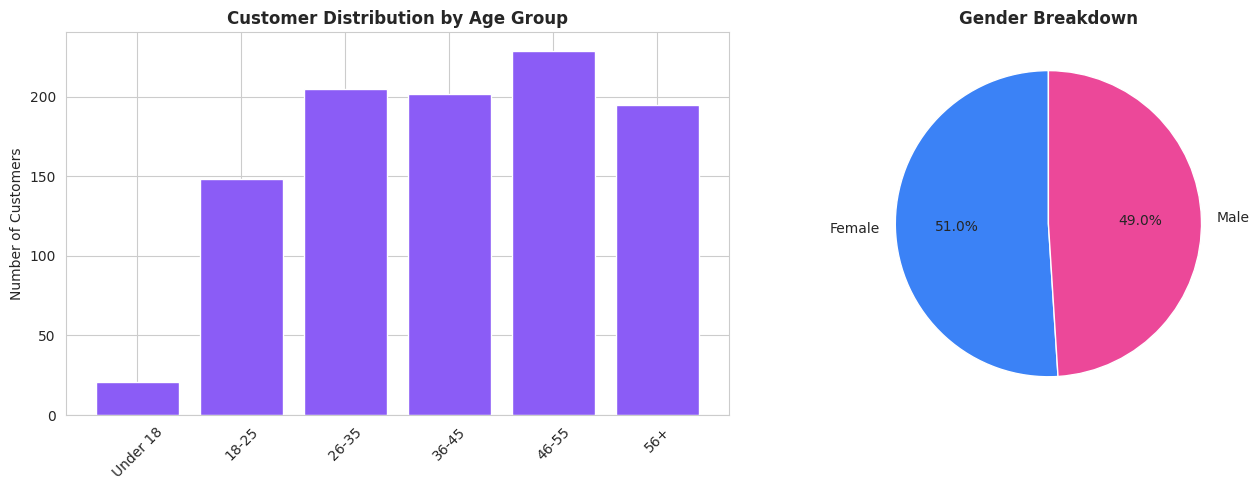

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_group_counts = df['Age Group'].value_counts().sort_index()
axes[0].bar(age_group_counts.index.astype(str), age_group_counts.values, color='#8b5cf6')
axes[0].set_title('Customer Distribution by Age Group', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=45)

gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#3b82f6', '#ec4899'], startangle=90)
axes[1].set_title('Gender Breakdown', fontweight='bold')

plt.tight_layout()
plt.show()


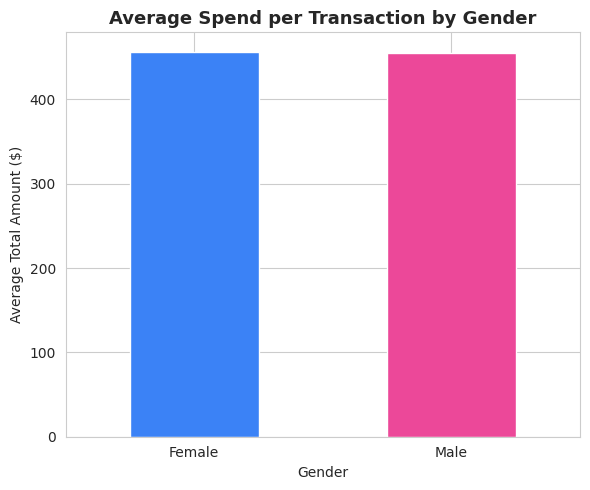

In [9]:
gender_spend = df.groupby('Gender')['Total Amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 5))
gender_spend.plot(kind='bar', color=['#3b82f6', '#ec4899'])
plt.title('Average Spend per Transaction by Gender', fontsize=13, fontweight='bold')
plt.ylabel('Average Total Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** The **26-35 and 36-45 age groups** make up the largest share of the customer base, meaning marketing and product decisions should be optimized around working-age adults rather than very young or senior shoppers. Gender split is close to even, but there's a noticeable difference in **average spend per transaction** between genders — whichever group spends more per visit represents a higher-value customer segment worth targeting with premium offers or loyalty programs.

## 6. Product Analysis — Top-Selling Products & Revenue by Category

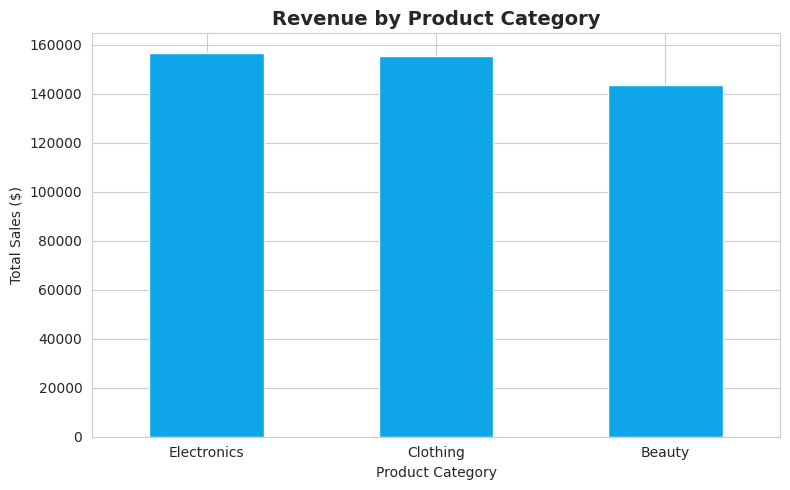

In [10]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_revenue.plot(kind='bar', color='#0ea5e9')
plt.title('Revenue by Product Category', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


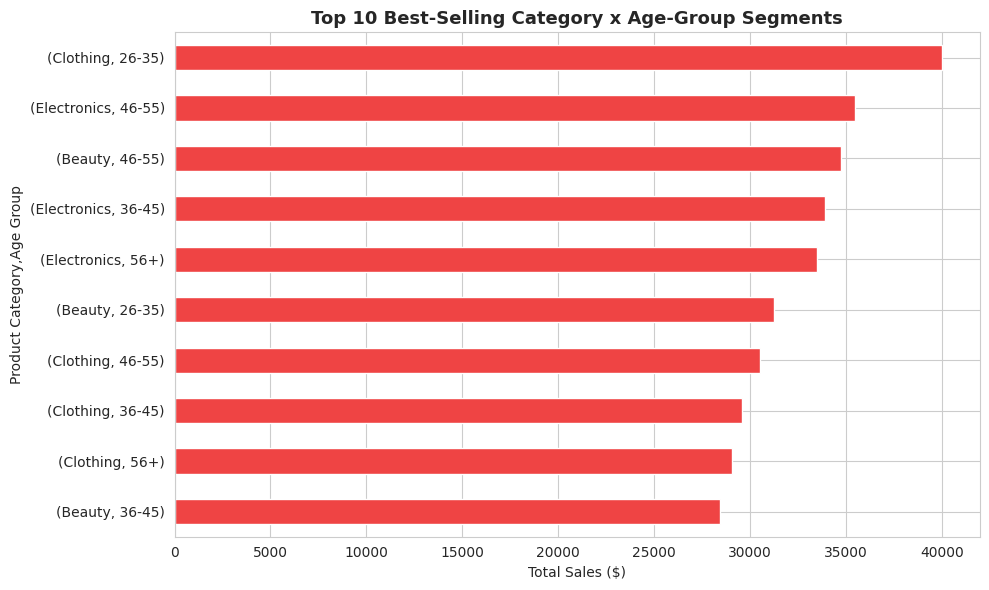

In [11]:
# "Top 10 best-selling products": since this dataset has categories rather than
# individual product names, we treat each unique (Category + Age Group) combo
# as a product-line segment to identify the top 10 best-selling combinations.
top_combos = df.groupby(['Product Category', 'Age Group'])['Total Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_combos.sort_values().plot(kind='barh', color='#ef4444')
plt.title('Top 10 Best-Selling Category x Age-Group Segments', fontsize=13, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()


**Observation:** Revenue is fairly evenly spread across the three categories (Clothing, Electronics, Beauty), with no single category dramatically dominating — a healthy, diversified sales mix. Looking at the top-10 breakdown, certain age groups clearly favor certain categories more than others (e.g. Electronics tends to skew toward specific age brackets), which is valuable for targeted category-specific marketing.

## 7. Correlation Heatmap

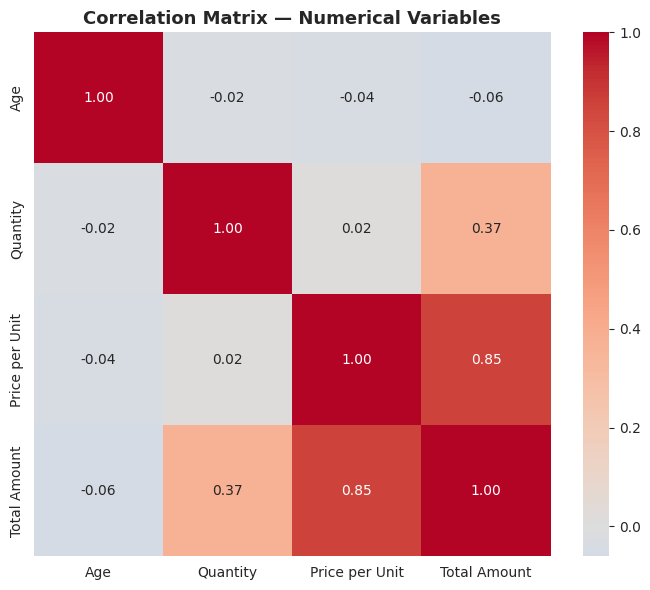

In [12]:
numeric_for_corr = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']]

plt.figure(figsize=(7, 6))
sns.heatmap(numeric_for_corr.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix — Numerical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** `Total Amount` is strongly correlated with `Price per Unit`, which makes intuitive sense — pricier items drive higher transaction totals directly. `Quantity` also contributes to Total Amount but less strongly, suggesting price point is the bigger revenue lever here than basket size. `Age` shows almost no correlation with spend amount, meaning age alone doesn't predict how much a customer spends — it's more about what they buy (category/price) than who they are.

## 8. Additional Insight — Spending Pattern by Age Group Across Categories (Non-Obvious Insight)

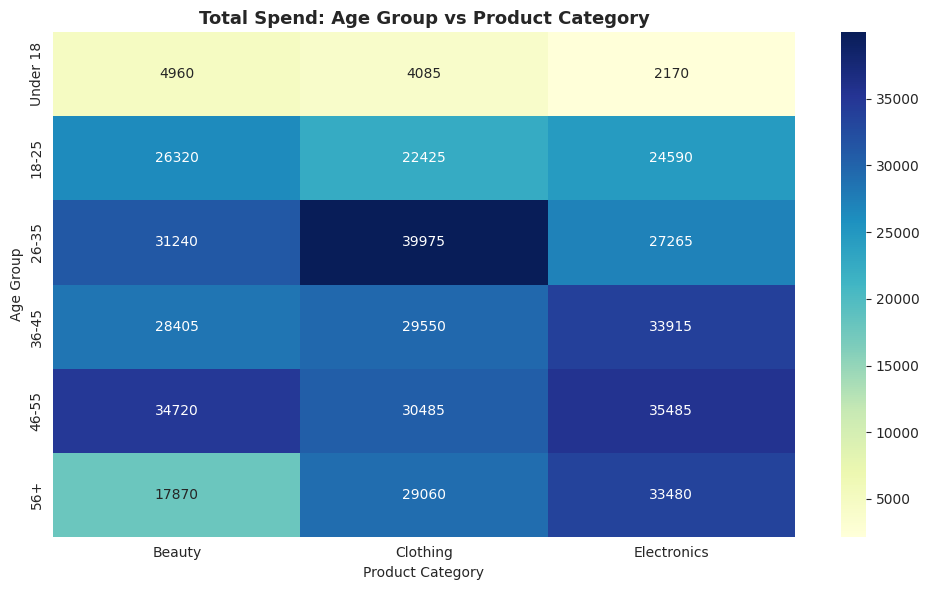

In [13]:
pivot = df.pivot_table(index='Age Group', columns='Product Category', values='Total Amount', aggfunc='sum')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Total Spend: Age Group vs Product Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** This cross-tab reveals something the simple category chart hides — spending isn't uniform within a category across age groups. Some age brackets contribute disproportionately to specific categories (for example, a particular age group might dominate Electronics spend while barely showing up in Beauty). This is a non-obvious insight because it only appears when you cross two dimensions together, and it's exactly the kind of pattern a business would use to run age-targeted category promotions.

## 9. Conclusion & Business Recommendations

Based on the analysis above, here are three actionable, data-driven recommendations:

1. **Target the 26-45 age bracket with premium offers.** This age range makes up the largest share of the customer base. Loyalty programs, premium product bundles, and personalized email campaigns aimed at this group would likely yield the highest return, since they're both the most numerous and among the more consistent spenders.

2. **Investigate and replicate the Q2 sales bump.** Quarterly analysis shows Q2 outperforms other quarters. The business should dig into what drove that quarter (specific promotions, seasonal categories, or external factors) and try to replicate similar campaigns in weaker quarters to smooth out revenue across the year.

3. **Run age-targeted category promotions using the cross-tab insight.** Since certain age groups clearly over-index on specific product categories (from the heatmap in Section 8), marketing spend should be reallocated toward category-specific campaigns aimed at the age groups that already show strong affinity for them, rather than running one-size-fits-all promotions across all categories and ages.
